# 06 - So sánh kết quả các Model (Naive Bayes / Logistic Regression / Linear SVM)

Notebook này đọc kết quả đã train sẵn trong `reports/` (không train lại) để vẽ các biểu đồ:

1. **Bar chart** so sánh Accuracy / Precision / Recall / F1-Score giữa 3 model.
2. **Confusion Matrix** cho từng model.
3. Bảng tổng hợp + kết luận model tốt nhất.

> Yêu cầu: đã chạy `python main.py --train-model` (hoặc notebook `05_training_and_evaluation.ipynb`) trước đó để sinh ra:
> - `reports/model_metrics.csv`
> - `reports/model_predictions.csv`


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cho phép import config.py ở thư mục gốc project khi chạy notebook trong notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import config

plt.rcParams["figure.dpi"] = 110
print("Project root:", PROJECT_ROOT)


Project root: /home/claude/spam_project/Project-Classifying-Spam-Emails-main


In [2]:
metrics_path = config.REPORTS_DIR / "model_metrics.csv"
predictions_path = config.REPORTS_DIR / "model_predictions.csv"

metrics_df = pd.read_csv(metrics_path)
predictions_df = pd.read_csv(predictions_path)

# Đặt tên hiển thị đẹp hơn cho từng model
MODEL_DISPLAY_NAMES = {
    "naive_bayes": "Naive Bayes",
    "logistic_regression": "Logistic Regression",
    "linear_svm": "Linear SVM",
}
metrics_df["model_display"] = metrics_df["model"].map(MODEL_DISPLAY_NAMES).fillna(metrics_df["model"])

metrics_df


,model,accuracy,precision_spam,recall_spam,f1_spam,model_display
0,linear_svm,0.979167,0.979007,0.979333,0.979170,Linear SVM
1,logistic_regression,0.974000,0.970394,0.977833,0.974099,Logistic Regression
2,naive_bayes,0.963417,0.977339,0.948833,0.962875,Naive Bayes


## 1. Bar chart so sánh Accuracy / Precision / Recall / F1-Score

Biểu đồ cột nhóm (grouped bar chart), mỗi nhóm là 1 model, mỗi cột trong nhóm là 1 chỉ số.
Ảnh sẽ được lưu vào `reports/figures/model_comparison_bar.png` để chèn vào báo cáo hoặc notebook khác.


Đã lưu: /home/claude/spam_project/Project-Classifying-Spam-Emails-main/reports/figures/model_comparison_bar.png


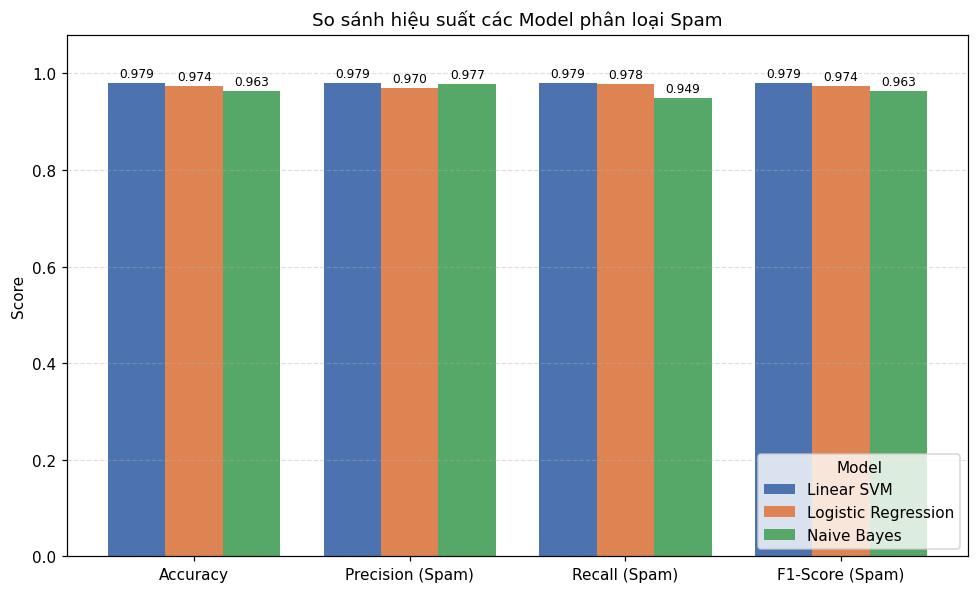

In [3]:
metric_cols = ["accuracy", "precision_spam", "recall_spam", "f1_spam"]
metric_labels = ["Accuracy", "Precision (Spam)", "Recall (Spam)", "F1-Score (Spam)"]

models = metrics_df["model_display"].tolist()
x = np.arange(len(metric_cols))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, (_, row) in enumerate(metrics_df.iterrows()):
    values = [row[col] for col in metric_cols]
    offset = (i - (len(models) - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=row["model_display"],
                   color=colors[i % len(colors)])
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("So sánh hiệu suất các Model phân loại Spam")
ax.legend(title="Model", loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
bar_chart_path = config.FIGURES_DIR / "model_comparison_bar.png"
fig.savefig(bar_chart_path, bbox_inches="tight")
print("Đã lưu:", bar_chart_path)

plt.show()


## 2. Confusion Matrix cho từng Model

Dùng cột `label` (nhãn thật) trong `model_predictions.csv` so với cột dự đoán của từng model.
Nhãn: `0 = Ham (not spam)`, `1 = Spam`.
Ảnh tổng hợp 3 confusion matrix sẽ lưu vào `reports/figures/confusion_matrices.png`.


Đã lưu: /home/claude/spam_project/Project-Classifying-Spam-Emails-main/reports/figures/confusion_matrices.png


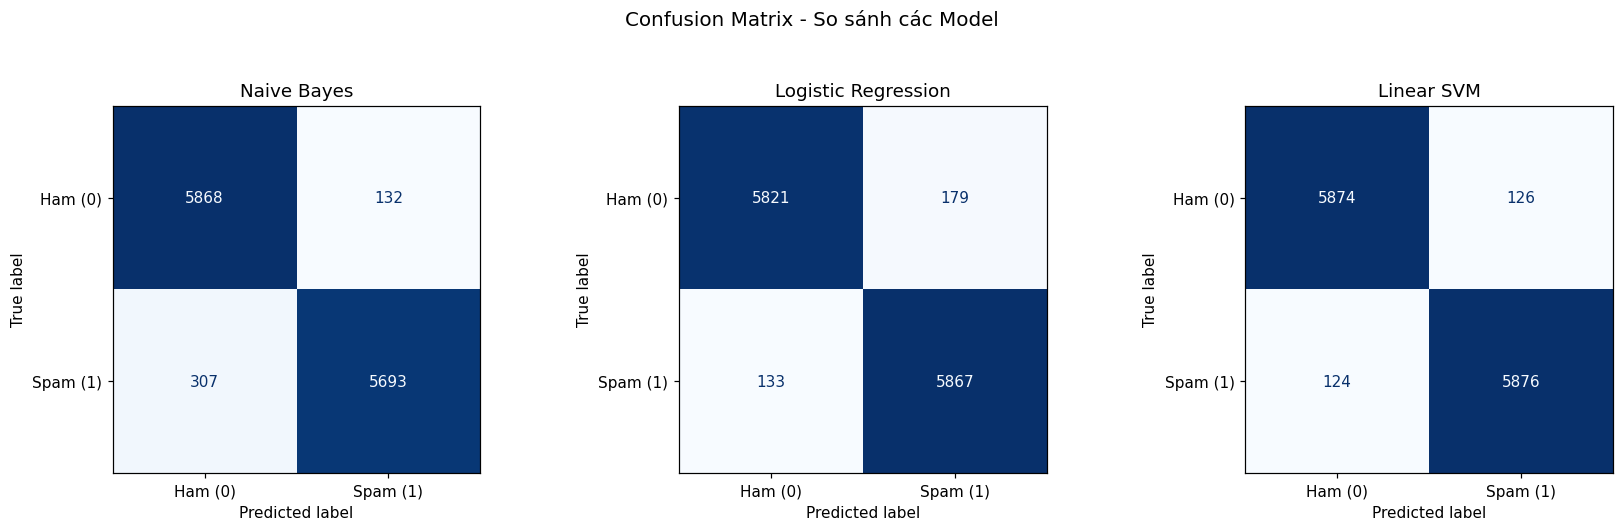

In [4]:
model_columns = [c for c in predictions_df.columns if c != "label"]
y_true = predictions_df["label"]

fig, axes = plt.subplots(1, len(model_columns), figsize=(5.2 * len(model_columns), 4.6))
if len(model_columns) == 1:
    axes = [axes]

for ax, model_col in zip(axes, model_columns):
    y_pred = predictions_df[model_col]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham (0)", "Spam (1)"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    display_name = MODEL_DISPLAY_NAMES.get(model_col, model_col)
    ax.set_title(display_name)

fig.suptitle("Confusion Matrix - So sánh các Model", y=1.04, fontsize=13)
fig.tight_layout()

cm_path = config.FIGURES_DIR / "confusion_matrices.png"
fig.savefig(cm_path, bbox_inches="tight")
print("Đã lưu:", cm_path)

plt.show()


## 3. Bảng tổng hợp & Model tốt nhất

Sắp xếp theo `f1_spam` giảm dần (giống tiêu chí chọn model trong `src/model_train.py`).


In [5]:
summary = metrics_df.sort_values(["f1_spam", "recall_spam"], ascending=False).reset_index(drop=True)
best_row = summary.iloc[0]

print(f"Model tốt nhất: {best_row['model_display']}  (F1-Score Spam = {best_row['f1_spam']:.4f})")

summary[["model_display", "accuracy", "precision_spam", "recall_spam", "f1_spam"]]


Model tốt nhất: Linear SVM  (F1-Score Spam = 0.9792)


,model_display,accuracy,precision_spam,recall_spam,f1_spam
0,Linear SVM,0.979167,0.979007,0.979333,0.979170
1,Logistic Regression,0.974000,0.970394,0.977833,0.974099
2,Naive Bayes,0.963417,0.977339,0.948833,0.962875


## Kết luận

- 2 ảnh đã được lưu vào `reports/figures/`:
  - `model_comparison_bar.png`
  - `confusion_matrices.png`
- Có thể chèn trực tiếp 2 ảnh này vào báo cáo Word (`reports/final_report.docx`) hoặc README.
- Nếu muốn train lại / cập nhật số liệu mới: chạy `python main.py --train-model` để sinh lại `model_metrics.csv` và `model_predictions.csv`, sau đó chạy lại notebook này.
